# MeatLens MobileNetV3Small — Full 12-Sample Dataset Final Training

This notebook trains the **final deployment model** using the complete 12-sample dataset
(`all_sampled_images.csv`). There is **no held-out test fold** — all 12 samples participate
in training. A 10% random stratified validation split is used **only** for early stopping
during training.

| Setting | Value |
|---|---|
| Architecture | MobileNetV3Small, CNN-only |
| Dataset | All 12 samples (8 MeatLens + 4 Public Dataset 2) |
| Splits | 90% train / 10% val (random stratified, per seed) |
| Seeds | 3 (42, 123, 2026) |
| Output root | `training_outputs/mobilenetv3small_12fold_fulldata_final_cnn_only/` |

> **Note**: Val-set metrics are reported only as a training stability check. They are **not**
> comparable to held-out test results from the 12-fold cross-validation notebook.


In [1]:
import importlib
import inspect

import pandas as pd
from IPython.display import Image as DisplayImage, display

import mobilenetv3small_12fold_fulldata_final_cnn_only_lib as libfd

libfd = importlib.reload(libfd)

print("Library source:", libfd.__file__)
print("SPLIT_ROOT:", libfd.SPLIT_ROOT)
print("EXTENSION_OUTPUT_ROOT:", libfd.EXTENSION_OUTPUT_ROOT)
print("ALL_SAMPLED_CSV:", libfd.ALL_SAMPLED_CSV)
print("EXTENSION_FOLDS:", libfd.EXTENSION_FOLDS)
print("EXTENSION_RUN_SEEDS:", libfd.EXTENSION_RUN_SEEDS)
print("VAL_SPLIT_FRACTION:", libfd.VAL_SPLIT_FRACTION)
print("USE_TRAINING_AUGMENTATION:", libfd.USE_TRAINING_AUGMENTATION)

libfd.ensure_output_dirs()
libfd.print_library_status()


[INFO] TensorFlow XLA/JIT disabled.
[INFO] TensorFlow XLA/JIT disabled.
[INFO] TensorFlow XLA/JIT disabled.
[INFO] TensorFlow XLA/JIT disabled.
[INFO] TensorFlow XLA/JIT disabled.
Library source: e:\Thesis Code\mobilenetv3small_12fold_fulldata_final_cnn_only_lib.py
SPLIT_ROOT: e:\Thesis Code\generated_splits\cross_rotation_interval200_12samples_processed_roi
EXTENSION_OUTPUT_ROOT: e:\Thesis Code\training_outputs\mobilenetv3small_12fold_fulldata_final_cnn_only
ALL_SAMPLED_CSV: e:\Thesis Code\generated_splits\cross_rotation_interval200_12samples_processed_roi\all_sampled_images.csv
EXTENSION_FOLDS: ['all']
EXTENSION_RUN_SEEDS: [42, 123, 2026]
VAL_SPLIT_FRACTION: 0.1
USE_TRAINING_AUGMENTATION: True
TF_AVAILABLE = True
SKLEARN_AVAILABLE = True
SKIMAGE_AVAILABLE = True
CV2_AVAILABLE = True
JOBLIB_AVAILABLE = True
SEABORN_AVAILABLE = True
PROJECT_ROOT = e:\Thesis Code
SPLIT_ROOT = e:\Thesis Code\generated_splits\cross_rotation_interval200_12samples_processed_roi
EXTENSION_OUTPUT_ROOT = e:\Th

## Step 1 — Load and Inspect the Full Dataset


In [2]:
all_df = libfd.load_all_fulldata_df()
print(f"Loaded {len(all_df)} rows from all_sampled_images.csv.")
print("Label counts:", all_df["label"].value_counts().to_dict())
print("Unique samples:", all_df["sample_id"].nunique())
print("Missing image paths:", int(all_df["missing_image_path"].sum()))
all_df.head(5)


[WARN] all_sampled_images.csv has 3 unresolved image paths — they will be dropped.
Loaded 6755 rows from all_sampled_images.csv.
Label counts: {'not fresh': 2324, 'spoiled': 2301, 'fresh': 2130}
Unique samples: 12
Missing image paths: 0


,image_file_name,sample_number,meat_part,label,time_frame,file_destination,sample_id,pork_cut,split_type,fold,source,split_key,split_name,dataset_partition,image_path_source_column,image_path_resolved,missing_image_path,capture_source,phone_group,phone_model
0,20260424_055602.jpg,1,Pork Shoulder,fresh,00:00:00,E:\Thesis Code\processed_hsv_lab_threshold_roi...,pork_shoulder_sample_1,shoulder,cross_rotation,all,meatlens,all,all,all,file_destination,E:\Thesis Code\processed_hsv_lab_threshold_roi...,False,researcher_home,old_phone,
1,IMG20260423061521.jpg,2,Pork Shoulder,fresh,00:00:00,E:\Thesis Code\processed_hsv_lab_threshold_roi...,pork_shoulder_sample_2,shoulder,cross_rotation,all,meatlens,all,all,all,file_destination,E:\Thesis Code\processed_hsv_lab_threshold_roi...,False,partner_home,old_phone,
2,20260429_042402.jpg,3,Pork Belly,fresh,00:00:00,E:\Thesis Code\processed_hsv_lab_threshold_roi...,pork_belly_sample_3,belly,cross_rotation,all,meatlens,all,all,all,file_destination,E:\Thesis Code\processed_hsv_lab_threshold_roi...,False,researcher_home,old_phone,
3,20260429_065044.jpg,4,Pork Belly,fresh,00:00:00,E:\Thesis Code\processed_hsv_lab_threshold_roi...,pork_belly_sample_4,belly,cross_rotation,all,meatlens,all,all,all,file_destination,E:\Thesis Code\processed_hsv_lab_threshold_roi...,False,partner_home,old_phone,
4,IMG_20260508_041534.jpg,5,Pork Ham,fresh,00:00:00,E:\Thesis Code\processed_hsv_lab_threshold_roi...,pork_ham_sample_5,ham,cross_rotation,all,meatlens,all,all,all,file_destination,E:\Thesis Code\processed_hsv_lab_threshold_roi...,False,researcher_home,new_phone,


In [3]:
# Show per-sample row counts
all_df.groupby(["sample_id", "pork_cut", "capture_source"])["label"].value_counts().unstack(fill_value=0)


,,label,fresh,not fresh,spoiled
sample_id,pork_cut,capture_source,,,
pork_belly_sample_10,belly,public_dataset_2,200,200,200
pork_belly_sample_3,belly,researcher_home,118,200,200
pork_belly_sample_4,belly,partner_home,150,200,199
pork_ham_sample_5,ham,researcher_home,200,200,200
pork_ham_sample_6,ham,partner_home,200,200,200
pork_hind_leg_sample_9,hind_leg,public_dataset_2,200,200,200
pork_loin_sample_7,loin,researcher_home,147,200,200
pork_loin_sample_8,loin,partner_home,200,200,200
pork_shoulder_sample_1,shoulder,researcher_home,200,200,200


## Step 2 — Preview the Train/Val Split for Each Seed


In [4]:
for seed in libfd.EXTENSION_RUN_SEEDS:
    train_df, val_df = libfd.split_fulldata_train_val(all_df, seed=seed)
    print(f"seed={seed}: train={len(train_df)} | val={len(val_df)}")
    print(f"  train labels: {train_df['label'].value_counts().to_dict()}")
    print(f"  val   labels: {val_df['label'].value_counts().to_dict()}")


seed=42: train=6080 | val=675
  train labels: {'not fresh': 2092, 'spoiled': 2071, 'fresh': 1917}
  val   labels: {'not fresh': 232, 'spoiled': 230, 'fresh': 213}
seed=123: train=6080 | val=675
  train labels: {'not fresh': 2092, 'spoiled': 2071, 'fresh': 1917}
  val   labels: {'not fresh': 232, 'spoiled': 230, 'fresh': 213}
seed=2026: train=6080 | val=675
  train labels: {'not fresh': 2092, 'spoiled': 2071, 'fresh': 1917}
  val   labels: {'not fresh': 232, 'spoiled': 230, 'fresh': 213}


In [5]:
# Optional: audit that all images resolve to 224x224 (slow — skippable)
# shape_audit = libfd.audit_image_shapes({"all_all": all_df})
# shape_audit
print("Shape audit skipped. Run manually if needed.")


Shape audit skipped. Run manually if needed.


## Step 3 — Sanity Checks


In [6]:
source = inspect.getsource(libfd.train_mobilenetv3small_fulldata_final_cnn_only_model)

checks = {
    "No fold CSV loading": "fold1_train" not in source,
    "No held-out test split": "test_df" not in source or "val_df" in source,
    "No handcrafted features": not any(kw in source for kw in ["glcm", "lab_", "hsv_", "StandardScaler"]),
    "Model name correct": "fulldata_final_cnn_only" in source,
    "ALL_SAMPLED_CSV points to correct folder": "cross_rotation_interval200_12samples_processed_roi" in str(libfd.ALL_SAMPLED_CSV),
    "VAL_SPLIT_FRACTION correct": libfd.VAL_SPLIT_FRACTION == 0.10,
}
for check_name, result in checks.items():
    print(f"  [{'OK' if result else 'FAIL'}] {check_name}")


  [OK] No fold CSV loading
  [OK] No held-out test split
  [OK] No handcrafted features
  [OK] Model name correct
  [OK] ALL_SAMPLED_CSV points to correct folder
  [OK] VAL_SPLIT_FRACTION correct


## Step 4 — Debug Single Run (Optional)


In [7]:
# Uncomment to run a single seed as a smoke test before full training:
# debug_result = libfd.run_single_fulldata_final_cnn_only_experiment(seed=42, all_df=all_df)
# print(debug_result)


## Step 5 — Full Training (3 Seeds)

Set `MANUAL_CONFIRM_RUN_FULL_TRAINING = True` to start training.


In [8]:
MANUAL_CONFIRM_RUN_FULL_TRAINING = True

if MANUAL_CONFIRM_RUN_FULL_TRAINING:
    all_results = libfd.run_fulldata_final_cnn_only_training()
    print("Training complete.")
    print("Best model bundle:", all_results.get("best_bundle"))
else:
    print("Full-dataset final training is ready but not started.")
    print("Set MANUAL_CONFIRM_RUN_FULL_TRAINING = True to train.")


[WARN] all_sampled_images.csv has 3 unresolved image paths — they will be dropped.
[run_fulldata_final] Loaded 6755 rows from all_sampled_images.csv.
Skipping completed run: seed=42
Skipping completed run: seed=123
Skipping completed run: seed=2026
Training complete.
Best model bundle: {'best_model_path': 'e:\\Thesis Code\\training_outputs\\mobilenetv3small_12fold_fulldata_final_cnn_only\\models\\meatlens_best_fulldata_final_cnn_only_mobilenetv3small.h5', 'best_tflite_path': 'e:\\Thesis Code\\training_outputs\\mobilenetv3small_12fold_fulldata_final_cnn_only\\models\\meatlens_best_fulldata_final_cnn_only_mobilenetv3small.tflite', 'best_metadata_path': 'e:\\Thesis Code\\training_outputs\\mobilenetv3small_12fold_fulldata_final_cnn_only\\models\\meatlens_best_fulldata_final_cnn_only_mobilenetv3small_metadata.json'}


## Step 6 — Results Review


In [9]:
if libfd.SEGMENTED6_SEED_METRICS_PATH.exists():
    seed_metrics_df = pd.read_csv(libfd.SEGMENTED6_SEED_METRICS_PATH)
    print(f"Completed seeds: {len(seed_metrics_df)}")
    display(seed_metrics_df[["seed", "train_count", "val_count",
                             "accuracy", "macro_f1", "adjacent_accuracy",
                             "severe_error_rate", "h5_size_mb", "tflite_size_mb",
                             "inference_mean_ms_per_image", "note"]].to_string(index=False))
else:
    print("No results yet. Run Step 5 first.")


Completed seeds: 3


' seed  train_count  val_count  accuracy  macro_f1  adjacent_accuracy  severe_error_rate  h5_size_mb  tflite_size_mb  inference_mean_ms_per_image                              note\n   42         6080        675  0.948148  0.948564           1.000000           0.000000    4.735298        3.880917                     2.618135 val_metrics_only_no_held_out_test\n  123         6080        675  0.930370  0.930797           0.997037           0.002963    4.735298        3.880917                     2.664764 val_metrics_only_no_held_out_test\n 2026         6080        675  0.928889  0.929206           0.995556           0.004444    4.735298        3.880917                     2.904689 val_metrics_only_no_held_out_test'

In [10]:
# Show the best model's metadata
import json
best_meta_path = libfd.EXTENSION_MODELS_ROOT / "meatlens_best_fulldata_final_cnn_only_mobilenetv3small_metadata.json"
if best_meta_path.exists():
    meta = json.loads(best_meta_path.read_text(encoding="utf-8"))
    for k, v in meta.items():
        print(f"  {k}: {v}")
else:
    print("Best model metadata not found yet.")


  model_name: meatlens_mobilenetv3small_12fold_fulldata_final_cnn_only
  backbone: MobileNetV3Small
  model_input_mode: cnn_only
  image_crop_mode: preprocessed_hsv_lab_threshold_roi_224
  input_shape: [224, 224, 3]
  target_size: [224, 224]
  label_order: ['fresh', 'not fresh', 'spoiled']
  label_to_index: {'fresh': 0, 'not fresh': 1, 'spoiled': 2}
  index_to_label: {'0': 'fresh', '1': 'not fresh', '2': 'spoiled'}
  split_mode: cross_rotation_interval200_12samples_fulldata_final
  fold_name: all
  seed: 42
  held_out_sample: none_fulldata
  held_out_cut: none
  capture_source: all_sources
  phone_group: all_groups
  accuracy: 0.9481481481481482
  macro_precision: 0.9487516227036518
  macro_recall: 0.9487812431812264
  macro_f1: 0.948564284406714
  top_2_accuracy: 0.997037037037037
  adjacent_accuracy: 1.0
  severe_error_rate: 0.0
  mean_absolute_ordinal_error: 0.0518518518518518
  model_path: e:\Thesis Code\training_outputs\mobilenetv3small_12fold_fulldata_final_cnn_only\models\meatle

fulldata_final_cnn_only_all_seed123_normalized_confusion_matrix.png


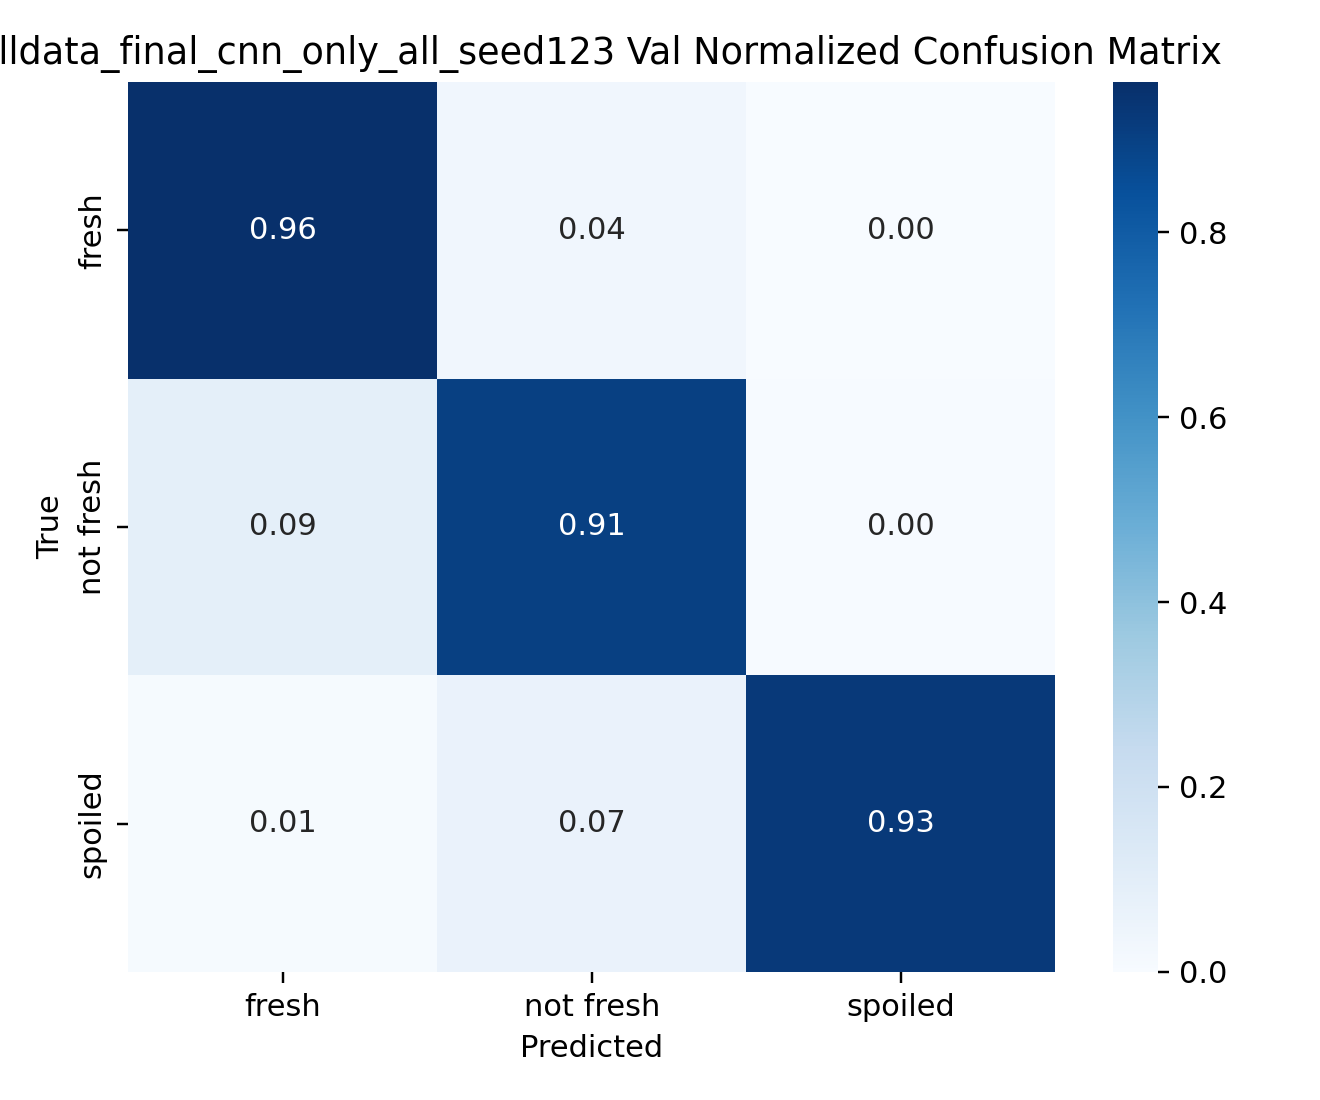

fulldata_final_cnn_only_all_seed2026_normalized_confusion_matrix.png


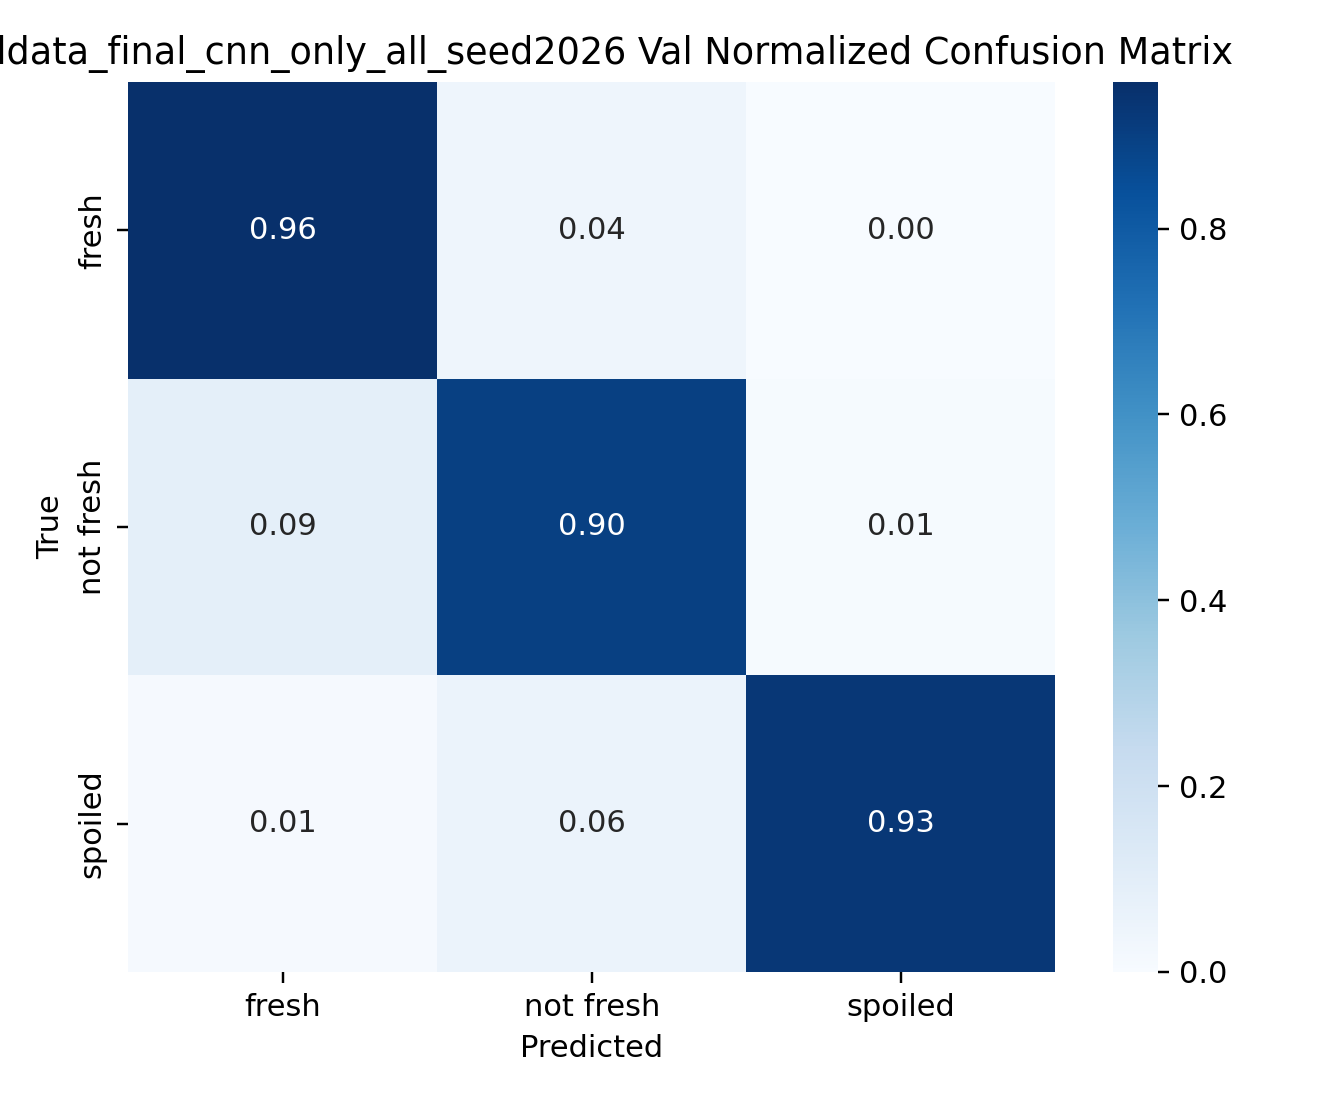

fulldata_final_cnn_only_all_seed42_normalized_confusion_matrix.png


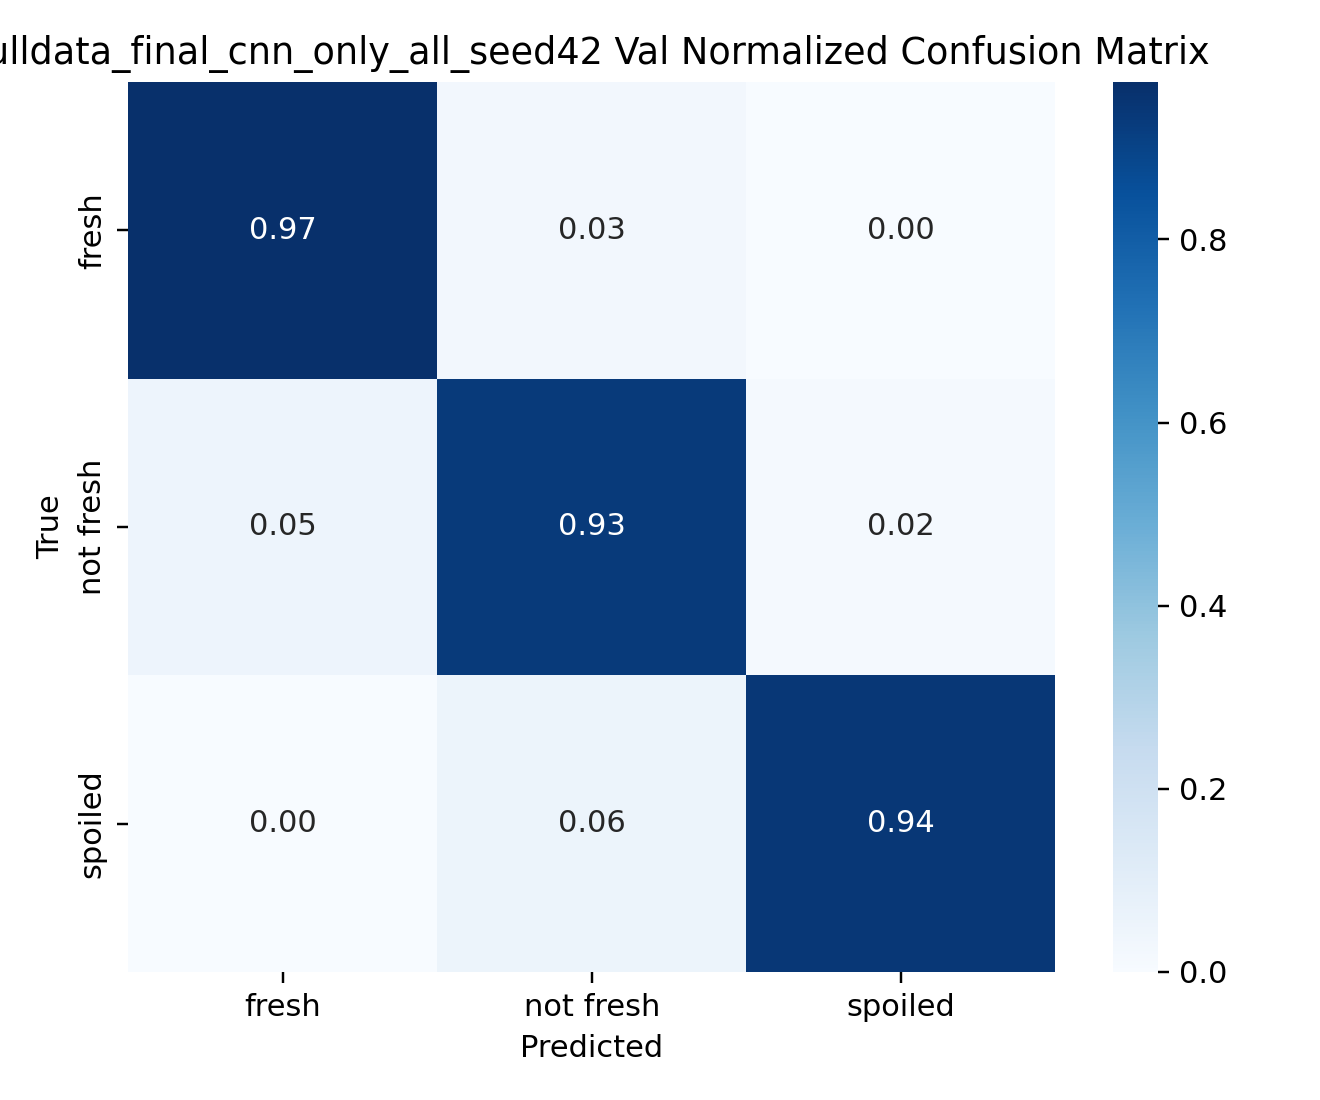

In [11]:
# Show saved confusion matrix figures
import os
figs_dir = libfd.EXTENSION_FIGURES_ROOT
if figs_dir.exists():
    fig_files = sorted(figs_dir.glob("fulldata_final_cnn_only_all_seed*_normalized_confusion_matrix.png"))
    for fig_path in fig_files:
        print(fig_path.name)
        display(DisplayImage(filename=str(fig_path)))
else:
    print("No figures directory yet.")


## Step 7 — Comparison with Cross-Validation Models


In [12]:
comparison_bundle = libfd.create_fulldata_final_vs_previous_models_comparison()
if comparison_bundle is not None:
    print("Comparison CSV:", comparison_bundle["comparison_csv_path"])
    comparison_bundle["comparison_df"]
else:
    print("No comparison data available yet (train first).")


Comparison CSV: e:\Thesis Code\training_outputs\mobilenetv3small_12fold_fulldata_final_cnn_only\fulldata_final_vs_previous_models_comparison.csv


## Step 8 — Summary Regeneration (After Training)


In [13]:
MANUAL_CONFIRM_REGENERATE_SUMMARIES = False

if MANUAL_CONFIRM_REGENERATE_SUMMARIES:
    regen_bundle = libfd.regenerate_metrics_summaries_and_graphs()
else:
    print("Summary regeneration ready but not started.")


Summary regeneration ready but not started.


## Completion Check


In [14]:
expected_seeds = libfd.EXTENSION_RUN_SEEDS
print("Expected seeds:", expected_seeds)

if libfd.SEGMENTED6_SEED_METRICS_PATH.exists():
    seed_metrics_df = pd.read_csv(libfd.SEGMENTED6_SEED_METRICS_PATH)
    completed_seeds = set(seed_metrics_df["seed"].astype(int).tolist())
    print("Completed seeds:", sorted(completed_seeds))
    missing = [s for s in expected_seeds if s not in completed_seeds]
    print("Missing seeds:", missing)
else:
    print("No training results yet.")

if libfd.SEGMENTED6_FAILED_RUNS_PATH.exists():
    print("Failed runs:")
    display(pd.read_csv(libfd.SEGMENTED6_FAILED_RUNS_PATH))
else:
    print("No failed runs logged.")


Expected seeds: [42, 123, 2026]
Completed seeds: [42, 123, 2026]
Missing seeds: []
Failed runs:


,timestamp,fold_name,seed,model_input_mode,image_crop_mode,error
0,2026-09-18T22:47:55.635639,all,42,cnn_only,preprocessed_hsv_lab_threshold_roi_224,InternalError()
1,2026-09-18T22:48:17.608333,all,123,cnn_only,preprocessed_hsv_lab_threshold_roi_224,"MemoryError((6080, 224, 224, 3), dtype('float3..."
2,2026-09-18T22:48:39.227446,all,2026,cnn_only,preprocessed_hsv_lab_threshold_roi_224,"MemoryError((6080, 224, 224, 3), dtype('float3..."
3,2026-09-18T23:07:03.517413,all,42,cnn_only,preprocessed_hsv_lab_threshold_roi_224,ResourceExhaustedError()
4,2026-09-18T23:09:55.438031,all,123,cnn_only,preprocessed_hsv_lab_threshold_roi_224,InternalError()
5,2026-09-18T23:13:16.720604,all,2026,cnn_only,preprocessed_hsv_lab_threshold_roi_224,ResourceExhaustedError()


---

This notebook trains the **final deployment MobileNetV3Small model** on all 12 pork samples.
Because no sample is held out, the val-set accuracy reflects training stability, not
generalisation. Use the 12-fold cross-validation notebook (`new10_mobilenetv3small_12fold_processed_roi_cnn_only.ipynb`)
for generalization estimates. The best model (by val macro F1) is automatically copied to
`training_outputs/mobilenetv3small_12fold_fulldata_final_cnn_only/models/meatlens_best_fulldata_final_cnn_only_mobilenetv3small.h5`.
